In [1]:
import earthaccess
import leafmap
from shapely.geometry import box
import rioxarray as rxr

In [2]:
import leafmap
m = leafmap.Map(zoom=3)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [4]:
bounds = m.user_roi_bounds()
bounds

[-22.4617, 63.8377, -21.7396, 64.1652]

In [5]:
earthaccess.login()
results_reflectance = earthaccess.search_data(
    short_name='MOD09GA',
    bounding_box=tuple(bounds),
    temporal=("2024-03", "2024-06"),
    count=1
)

results_temperature = earthaccess.search_data(
    short_name='MOD11A1',
    bounding_box=tuple(bounds),
    temporal=("2024-03", "2024-06"),
    count=1
)


In [7]:
reflectance = earthaccess.download(results_reflectance,"./")
temperature = earthaccess.download(results_temperature,"./")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
import numpy as np
from osgeo import gdal
import os

def open_subdataset(hdf_path, subdataset_name):
    """Open a subdataset from an HDF4 file"""
    ds = gdal.Open(hdf_path)
    for name, desc in ds.GetSubDatasets():
        if subdataset_name in name:
            return gdal.Open(name)
    raise ValueError(f"Subdataset '{subdataset_name}' not found in {hdf_path}")

def resample_to_match(source_ds, target_ds, method='nearest'):
    """Resample source dataset to match size and extent of target dataset"""
    temp_path = '/tmp/resampled.tif'

    # Get geotransform and dimensions
    gt = target_ds.GetGeoTransform()
    xmin = gt[0]
    ymax = gt[3]
    xmax = xmin + gt[1] * target_ds.RasterXSize
    ymin = ymax + gt[5] * target_ds.RasterYSize

    gdal.Warp(temp_path, source_ds,
              format='GTiff',
              width=target_ds.RasterXSize,
              height=target_ds.RasterYSize,
              dstSRS=target_ds.GetProjection(),
              resampleAlg=method,
              outputBounds=(xmin, ymin, xmax, ymax))
    
    return gdal.Open(temp_path)

def compute_albedo(bands):
    """Compute broadband albedo from MODIS bands"""
    # Convert reflectance to [0, 1] scale
    refl = [b.astype(np.float32) * 0.0001 for b in bands]
    albedo = 0.160 * refl[0] + 0.291 * refl[1] + 0.243 * refl[2] + 0.116 * refl[3] + 0.112 * refl[4] + 0.081 * refl[6] + -.0015
    return albedo

def compute_ati(albedo, lst_day, lst_night, cloud_mask):
    """Compute Apparent Thermal Inertia"""
    delta_lst = lst_day - lst_night
    ati = np.where((cloud_mask) & (delta_lst > 0),
                   (1 - albedo) / delta_lst,
                   np.nan)
    return ati

# --- Input files ---
mod11a1 = temperature[0]
mod09ga = reflectance[0]
output_file = "ATI.tif"

# --- Load Reflectance bands ---
bands = []
for i in range(1, 8):  # Bands 1–7
    b = open_subdataset(mod09ga, f'MODIS_Grid_500m_2D:sur_refl_b0{i}_1')
    bands.append(b.ReadAsArray())

# Use band 1 as reference for projection/resampling
ds_ref = open_subdataset(mod09ga, 'MODIS_Grid_500m_2D:sur_refl_b01_1')

# --- Compute Albedo ---
albedo = compute_albedo(bands)

# --- Load and resample LST Day/Night (1km to 500m) ---
lst_day_ds = open_subdataset(mod11a1, 'MODIS_Grid_Daily_1km_LST:LST_Day_1km')
lst_night_ds = open_subdataset(mod11a1, 'MODIS_Grid_Daily_1km_LST:LST_Night_1km')
lst_day = resample_to_match(lst_day_ds, ds_ref, method='bilinear').ReadAsArray() * 0.02
lst_night = resample_to_match(lst_night_ds, ds_ref, method='bilinear').ReadAsArray() * 0.02

# --- Cloud Mask (QA) from state_1km_1 ---
qa_ds = open_subdataset(mod09ga, 'MODIS_Grid_1km_2D:state_1km_1')
qa_resampled = resample_to_match(qa_ds, ds_ref, method='nearest')
qa_array = qa_resampled.ReadAsArray()
cloud_mask = (qa_array & 0b11) == 0  # Bits 0–1 == 00 (clear)

# --- Compute ATI ---
ati = compute_ati(albedo, lst_day, lst_night, cloud_mask)

# --- Save to GeoTIFF ---
f = rxr.open_rasterio(reflectance[0])
test = f[1]['sur_refl_b01_1'][0]
test.values = ati

test.rio.to_raster(output_file)

print(f"✅ ATI saved to: {output_file}")


✅ ATI saved to: ATI.tif


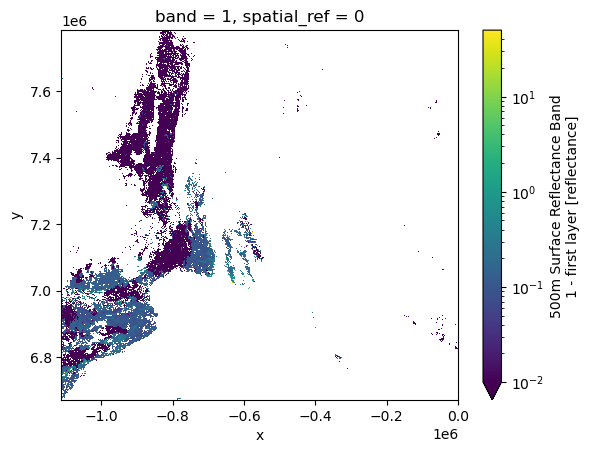

In [33]:
import matplotlib.colors as colors
ati = rxr.open_rasterio("ATI.tif")
ati.plot(norm=colors.LogNorm(), vmin=1e-2)